# Hisse Senedi Fiyat Tahmini İçin Makine Öğrenmesi Yaklaşımlarının Karşılaştırılması

## Giriş

Bu projenin amacı, geçmiş hisse senedi verilerini kullanarak fiyat hareketlerinin yükseliş mi yoksa düşüş mü olacağını tahmin etmektir. Projede teknik analiz göstergeleri kullanılarak feature engineering işlemleri uygulanmış ve elde edilen veriler makine öğrenmesi modellerine verilmiştir.

Finansal piyasalardaki fiyat hareketleri yalnızca geçmiş verilere bağlı değildir. Ekonomik gelişmeler, şirket haberleri, siyasi olaylar, küresel krizler ve yatırımcı davranışları gibi birçok dış faktör hisse senedi fiyatlarını doğrudan etkileyebilmektedir. Bu nedenle hisse senedi tahmini, makine öğrenmesi açısından oldukça karmaşık ve zor bir problem olarak değerlendirilmektedir.

Proje kapsamında Logistic Regression, XGBoost ve LSTM modelleri kullanılmıştır. Logistic Regression temel doğrusal sınıflandırma modeli olarak tercih edilmiştir. XGBoost karmaşık ilişkileri öğrenebilmesi nedeniyle kullanılmıştır. LSTM modeli ise zaman serisi verilerindeki geçmiş bağımlılıklarını öğrenebilmek amacıyla projeye dahil edilmiştir.

Model performanslarını değerlendirmek için Accuracy, F1 Score, AUC, ROC Curve ve Confusion Matrix metrikleri kullanılmıştır. Özellikle sınıf dengesizliği bulunduğu için yalnızca accuracy yerine F1 Score ve AUC değerleri de dikkate alınmıştır.

Model performansını artırmak amacıyla çeşitli hiperparametre ayarlamaları yapılmıştır. LSTM modelinde dropout, recurrent dropout, batch normalization, learning rate, batch size ve epoch değerleri düzenlenmiştir. XGBoost modelinde ise max_depth, learning_rate, n_estimators ve scale_pos_weight gibi hiperparametreler optimize edilmiştir.

Ayrıca modeller üzerinde hiperparametre optimizasyonu yapılarak overfitting probleminin azaltılması hedeflenmiştir.


# Veri Yükleme ve Veri Seti

In [4]:
# ==================== BLOK 1: KÜTÜPHANELER ====================
!pip install -q streamlit yfinance xgboost joblib scikit-learn
!npm install -g localtunnel
# Veri işleme işlemleri için kullanılır
import pandas as pd

# Matematiksel işlemler için kullanılır
import numpy as np

# Grafik çizimleri için kullanılır
import matplotlib.pyplot as plt

# Yahoo Finance üzerinden hisse verisi çekmek için kullanılır
import yfinance as yf

# LSTM derin öğrenme modeli için kullanılır
import tensorflow as tf

from datetime import date

# Grafik görünüm temasını ayarlar
plt.style.use('ggplot')


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



changed 22 packages in 2s

3 packages are looking for funding
  run `npm fund` for details


In [5]:
# Veri aralığı
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")



# ==================== VERİ YÜKLEME FONKSİYONU ====================

def load_data(ticker):

    # Yahoo Finance üzerinden hisse verisini indirir
    data = yf.download(ticker,START,TODAY)

    # Bazı hisselerde oluşan MultiIndex kolon problemini düzeltir
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # Tarihi normal sütuna çevirir
    data.reset_index(inplace=True)

    return data

Yahoofinans kütüphanesinden veri kümesini getirmek için başlangıç gününü tanımlıyoruz.
Başlangıç günümüzü 01.01.2010 olarak belirledik.

In [6]:
# ==================== VERİYİ YÜKLEME ====================

# TCS hissesi verisini yükler
data = load_data('TCS.NS')

# Veri setini df değişkenine aktarır
df = data.copy()

# İlk 5 satırı gösterir
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2010-01-04,262.774536,265.309114,261.865571,263.875754,1963682
1,2010-01-05,262.844360,265.536260,260.991501,263.945599,2014488
2,2010-01-06,256.901215,262.966732,256.254469,262.844361,3349176
3,2010-01-07,249.752014,258.491936,248.563376,257.128500,6474892
4,2010-01-08,244.647873,251.185338,243.494208,250.311346,6048178


Veri seti içerisinde tarih, açılış fiyatı, kapanış fiyatı, en yüksek fiyat, en düşük fiyat ve işlem hacmi bilgileri bulunmaktadır.
Hindistan borsa verilerinin ilk 5 satırını görüntülüyoruz.

# KEŞİFSEL VERİ ANALİZİ (EDA)

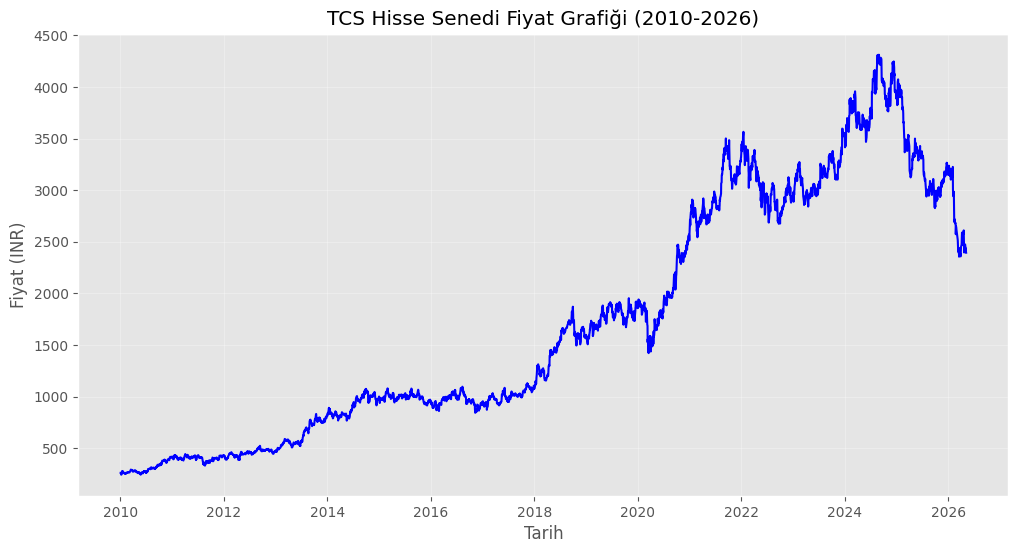

In [7]:
# ==================== TÜM VERİ GRAFİĞİ ====================

plt.figure(figsize=(12, 6))

# Kapanış fiyatlarını çizer
plt.plot(
    df['Date'],
    df['Close'],
    color='blue',
    linewidth=1.5
)

# Grafik başlığı
plt.title("TCS Hisse Senedi Fiyat Grafiği (2010-2026)")

# Eksen isimleri
plt.xlabel("Tarih")
plt.ylabel("Fiyat (INR)")

# Grid çizgileri
plt.grid(True, alpha=0.3)

plt.show()

Grafik incelendiğinde TCS hisse fiyatlarının yıllar içerisinde genel olarak yükseliş trendi gösterdiği gözlemlenmiştir. Özellikle 2020 sonrası dönemde fiyat hareketlerinde daha yüksek volatilite oluşmuştur.

In [8]:
# ==================== 100 GÜNLÜK HAREKETLİ ORTALAMA ====================

# 100 günlük hareketli ortalamayı hesaplar
ma100 = df['Close'].rolling(100).mean()

# İlk değerleri gösterir
ma100.head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Close, dtype: float64

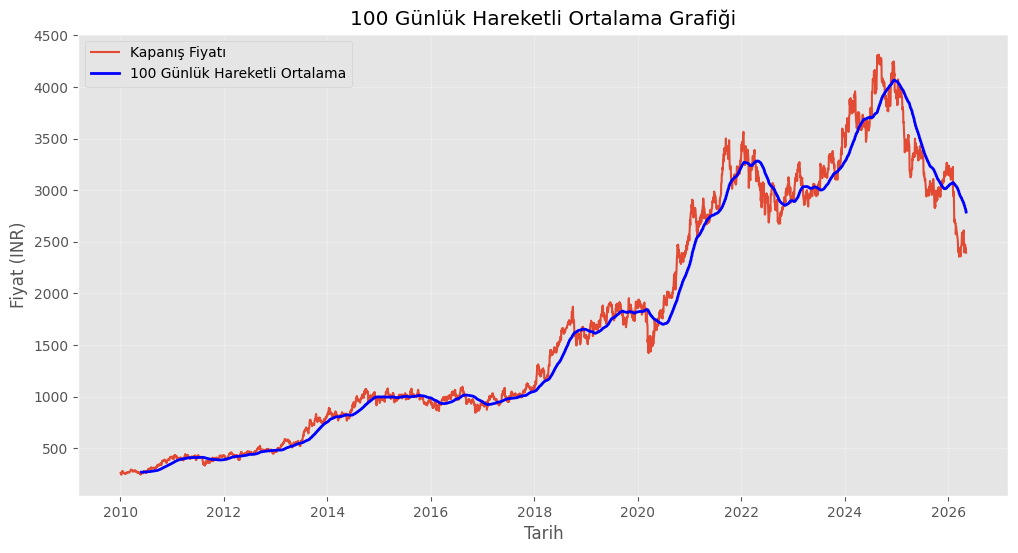

In [9]:
# ==================== 100 GÜNLÜK HAREKETLİ ORTALAMA GRAFİĞİ ====================

plt.figure(figsize=(12,6))

# Gerçek kapanış fiyatı
plt.plot(
    df['Date'],
    df['Close'],
    label='Kapanış Fiyatı',
    linewidth=1.5
)

# 100 günlük hareketli ortalama
plt.plot(
    df['Date'],
    ma100,
    'b',
    label='100 Günlük Hareketli Ortalama',
    linewidth=2
)

plt.title("100 Günlük Hareketli Ortalama Grafiği")


plt.xlabel("Tarih")
plt.ylabel("Fiyat (INR)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

100 günlük hareketli ortalama kullanılarak kısa ve orta vadeli fiyat trendleri analiz edilmiştir. Hareketli ortalama çizgisi fiyat dalgalanmalarını yumuşatarak genel trendin daha net görülmesini sağlamıştır.

In [10]:
# ==================== 200 GÜNLÜK HAREKETLİ ORTALAMA ====================

# 200 günlük hareketli ortalamayı hesaplar
ma200 = df['Close'].rolling(200).mean()

# İlk değerleri gösterir
ma200.head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Close, dtype: float64

200 günlük hareketli ortalama uzun vadeli trend analizi amacıyla kullanılmıştır. Uzun dönemli hareketli ortalama fiyat değişimlerinin genel yönünü belirlemede yardımcı olmuştur.

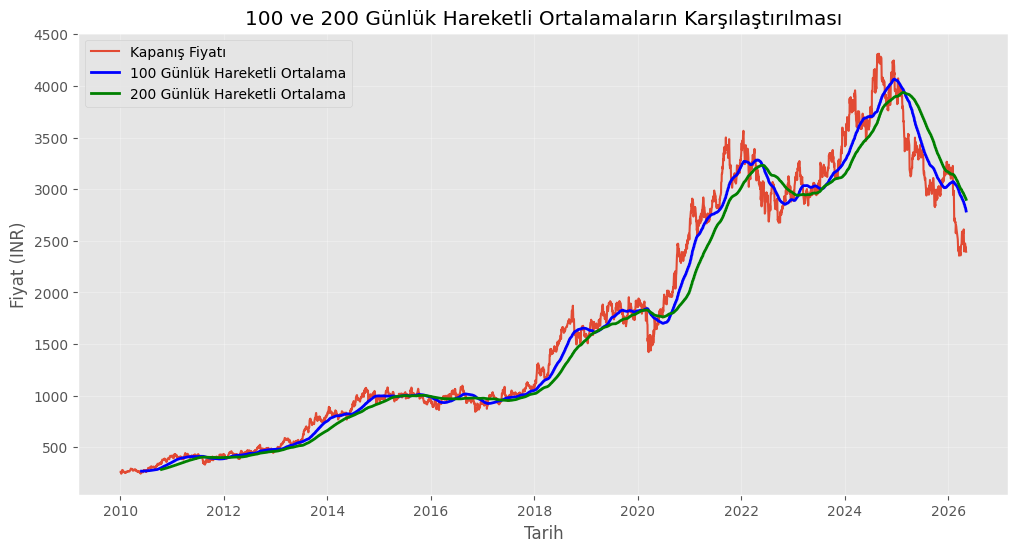

In [11]:
# ==================== 100 VE 200 GÜNLÜK HAREKETLİ ORTALAMA GRAFİĞİ ====================

plt.figure(figsize=(12,6))

# Kapanış fiyatı grafiği
plt.plot(
    df['Date'],
    df['Close'],
    label='Kapanış Fiyatı',
    linewidth=1.5
)

# 100 günlük hareketli ortalama grafiği
plt.plot(
    df['Date'],
    ma100,
    'b',
    label='100 Günlük Hareketli Ortalama',
    linewidth=2
)

# 200 günlük hareketli ortalama grafiği
plt.plot(
    df['Date'],
    ma200,
    'g',
    label='200 Günlük Hareketli Ortalama',
    linewidth=2
)

plt.title(
    '100 ve 200 Günlük Hareketli Ortalamaların Karşılaştırılması'
)

plt.xlabel("Tarih")
plt.ylabel("Fiyat (INR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Hisse senedi fiyatlarının zaman içindeki değişimini gösterirken aynı zamanda 100 
günlük ve 200 günlük hareketli ortalamaların karşılaştırmasını yapar. 

#  FEATURE ENGINEERING

In [12]:
# ==================== FEATURE ENGINEERING ====================

# Veri kopyası
df = data.copy()

# ================= HAREKETLİ ORTALAMALAR =================

df['MA10'] = df['Close'].rolling(10).mean()

df['MA30'] = df['Close'].rolling(30).mean()
# Bollinger Bands
rolling_std = df['Close'].rolling(20).std()

df['Upper_Band'] = (
    df['MA30'] + (rolling_std * 2)
)

df['Lower_Band'] = (
    df['MA30'] - (rolling_std * 2)
)
# EMA (Daha güçlü trend feature)
df['EMA10'] = df['Close'].ewm(span=10).mean()

df['EMA30'] = df['Close'].ewm(span=30).mean()

# Trend yönü
df['Trend'] = (
    df['EMA10'] > df['EMA30']
).astype(int)

# ================= VOLATILITY =================

df['Volatility'] = df['Close'].rolling(20).std()

# Günlük fiyat aralığı
df['Price_Range'] = (
    df['High'] - df['Low']
) / df['Close']

# ================= RSI =================

delta = df['Close'].diff()

gain = delta.clip(lower=0).rolling(14).mean()

loss = (-delta.clip(upper=0)).rolling(14).mean()

rs = gain / loss

df['RSI'] = 100 - (100 / (1 + rs))

# ================= MACD =================

ema12 = df['Close'].ewm(span=12, adjust=False).mean()

ema26 = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = ema12 - ema26

# MACD Signal
df['MACD_Signal'] = (
    df['MACD']
    .ewm(span=9, adjust=False)
    .mean()
)

# MACD Histogram
df['MACD_Hist'] = (
    df['MACD']
    - df['MACD_Signal']
)

# ================= MOMENTUM =================

df['Momentum'] = (
    df['Close']
    - df['Close'].shift(10)
)

# ================= VOLUME FEATURE =================

df['Volume_Change'] = (
    df['Volume'].pct_change()
)

# ================= RETURN =================

df['Return'] = df['Close'].pct_change()
# Smoothed Return
df['Smoothed_Return'] = (
    df['Return'].rolling(5).mean()
)
# ================= TARGET =================

future_return = (
    df['Close'].shift(-5)
    - df['Close']
) / df['Close']

# Hedef değişken
df['Future_Return'] = (
    df['Close'].shift(-3) - df['Close']
) / df['Close']

df['Target'] = (
    df['Future_Return'] > 0.005
).astype(int)

# ================= EKSİK VERİLER =================
# Infinity değerlerini temizler
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Eksik verileri temizler
df.dropna(inplace=True)

print(" Feature engineering tamamlandı")

print(df.head())

 Feature engineering tamamlandı
Price       Date       Close        High         Low        Open   Volume  \
29    2010-02-16  265.749695  268.133253  260.158835  261.928976  1660490   
30    2010-02-17  265.924957  269.184825  263.786749  268.115732  2528290   
31    2010-02-18  265.977356  268.834132  264.820632  266.397989  1814806   
32    2010-02-19  263.085754  266.222948  261.420766  264.610546  2215880   
33    2010-02-22  265.434174  267.695057  264.224862  265.346543  2143460   

Price        MA10        MA30  Upper_Band  Lower_Band  ...        RSI  \
29     259.112477  262.321377  275.873109  248.769644  ...  51.645197   
30     259.822298  262.426391  273.283613  251.569169  ...  56.999539   
31     260.027342  262.530824  272.315643  252.746004  ...  57.875163   
32     260.442723  262.736975  271.154000  254.319950  ...  56.467110   
33     261.625734  263.259714  271.026463  255.492965  ...  55.153227   

Price      MACD  MACD_Signal  MACD_Hist   Momentum  Volume_Change 

C:\Users\zhany\AppData\Local\Temp\ipykernel_22820\10686384.py:88: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['Close'].pct_change()


Bu aşamada ham hisse senedi verileri üzerinde feature engineering işlemleri uygulanmıştır. Modelin fiyat hareketlerini daha iyi öğrenebilmesi için hareketli ortalamalar (MA10, MA30), Bollinger Bands, EMA, RSI, MACD, volatilite, momentum ve günlük getiri gibi teknik göstergeler oluşturulmuştur.

Ayrıca gelecekteki fiyat değişimine göre Target değişkeni tanımlanarak sınıflandırma problemi hazırlanmıştır. Eksik ve sonsuz değerler temizlenerek veri modeli eğitime uygun hale getirilmiştir.

Veri seti model eğitimi ve performans değerlendirmesi için train ve test olarak ayrılmıştır. Verilerin yaklaşık %70’i eğitim, %30’u ise test amacıyla kullanılmıştır.

# KEŞİFSEL VERİ ANALİZİ (EDA)

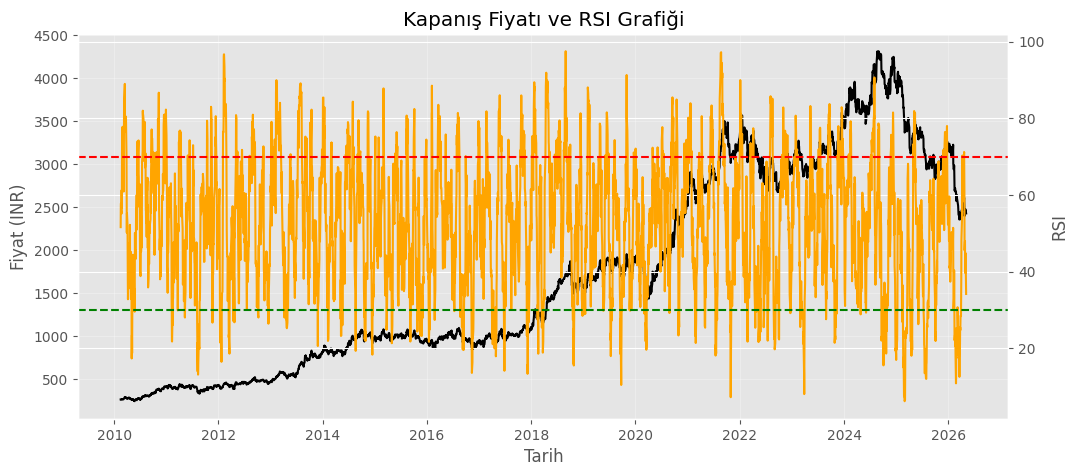

In [13]:
# ==================== VERİ GÖRSELLEŞTİRME ====================

import matplotlib.pyplot as plt
import seaborn as sns

# ================= KAPANIŞ FİYATI VE RSI GRAFİĞİ =================

fig, ax1 = plt.subplots(figsize=(12,5))

# Kapanış fiyatı grafiği
ax1.plot(
    df['Date'],
    df['Close'],
    color='black',
    label='Kapanış Fiyatı'
)

ax1.set_ylabel("Fiyat (INR)")
ax1.set_xlabel("Tarih")

# RSI için ikinci eksen
ax2 = ax1.twinx()

ax2.plot(
    df['Date'],
    df['RSI'],
    color='orange',
    label='RSI'
)

# RSI sınırları
ax2.axhline(70, linestyle='--', color='red')
ax2.axhline(30, linestyle='--', color='green')

ax2.set_ylabel("RSI")

# Başlık
plt.title("Kapanış Fiyatı ve RSI Grafiği")

# Grid
ax1.grid(True, alpha=0.3)

plt.show()

RSI (Relative Strength Index), fiyatın ne kadar güçlü yükseldiğini veya düştüğünü gösteren teknik analiz göstergesidir.

Bu görselleştirmede hisse senedinin kapanış fiyatı ile RSI göstergesi birlikte incelenmiştir. Siyah çizgi hisse fiyatındaki değişimi gösterirken turuncu çizgi RSI değerlerini göstermektedir.

RSI göstergesinde 70 seviyesi aşırı alım, 30 seviyesi ise aşırı satım bölgesi olarak değerlendirilmiştir. Grafik incelendiğinde fiyat hareketleri ile RSI arasında dönemsel ilişki olduğu gözlemlenmiştir.

**Korelasyon Matrisi**

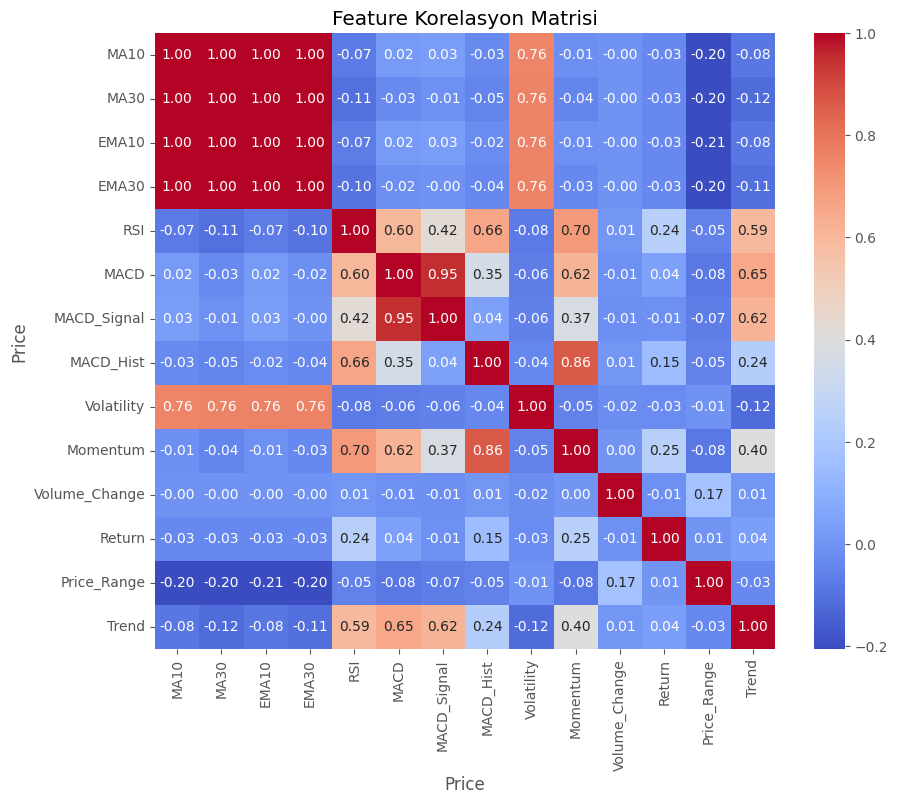

In [14]:
# ==================== KORELASYON MATRİSİ ====================

# Korelasyon için kullanılacak feature'lar
features_for_correlation = [

    'MA10',
    'MA30',
    'EMA10',
    'EMA30',
    'RSI',
    'MACD',
    'MACD_Signal',
    'MACD_Hist',
    'Volatility',
    'Momentum',
    'Volume_Change',
    'Return',
    'Price_Range',
    'Trend'
]

# Grafik boyutu
plt.figure(figsize=(10,8))
# MultiIndex kolon temizleme
df.columns = df.columns.get_level_values(-1)
# Korelasyon matrisi
sns.heatmap(
    df[features_for_correlation].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Korelasyon Matrisi")
plt.show()

Bu aşamada feature’lar arasındaki ilişkileri incelemek için korelasyon matrisi oluşturulmuştur. Korelasyon matrisi sayesinde değişkenlerin birbirleriyle pozitif veya negatif ilişkileri analiz edilmiştir.

Grafikte kırmızı tonlar pozitif ilişkiyi, mavi tonlar ise negatif ilişkiyi göstermektedir. Özellikle MA, EMA ve MACD gibi bazı teknik göstergeler arasında yüksek korelasyon olduğu gözlemlenmiştir. Bu analiz, model üzerinde etkili feature’ların anlaşılmasına yardımcı olmuştur.

Korelasyon matrisi incelendiğinde bazı teknik göstergeler arasında güçlü ilişkiler olduğu görülmektedir. Özellikle MA10, MA30, EMA10 ve EMA30 feature’ları arasında yüksek pozitif korelasyon bulunmaktadır. Bunun nedeni bu göstergelerin benzer trend bilgilerini üretmesidir.

Ayrıca MACD, Momentum ve RSI feature’ları arasında da orta ve yüksek seviyede ilişkiler gözlemlenmiştir. Volume_Change ve Return gibi bazı değişkenlerin ise diğer feature’larla daha düşük korelasyona sahip olduğu görülmektedir. Bu analiz sayesinde feature’ların veri üzerindeki etkileri daha iyi anlaşılmıştır.

**TARGET SINIF DAĞILIMI**

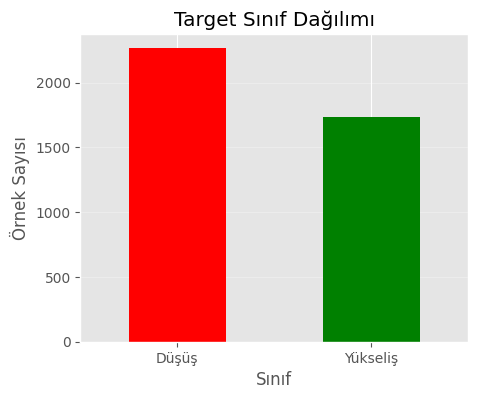

In [15]:
# ==================== TARGET SINIF DAĞILIMI ====================

plt.figure(figsize=(5,4))

# Target sınıflarının dağılımı
df['Target'].value_counts().plot(
    kind='bar',
    color=['red', 'green']
)

# X ekseni etiketleri
plt.xticks(
    [0,1],
    ['Düşüş', 'Yükseliş'],
    rotation=0
)

# Eksen isimleri
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")


plt.title("Target Sınıf Dağılımı")
plt.grid(True, alpha=0.3, axis='y')
plt.show()

Bu grafikte hedef değişkenin sınıf dağılımı incelenmiştir. Veri setinde düşüş ve yükseliş sınıflarının sayıları karşılaştırılmıştır.

Grafik incelendiğinde düşüş sınıfının yükseliş sınıfına göre daha fazla olduğu görülmektedir. Ancak sınıflar arasında aşırı dengesizlik bulunmamaktadır. Bu durum modelin her iki sınıfı da öğrenebilmesi açısından avantaj sağlamaktadır.

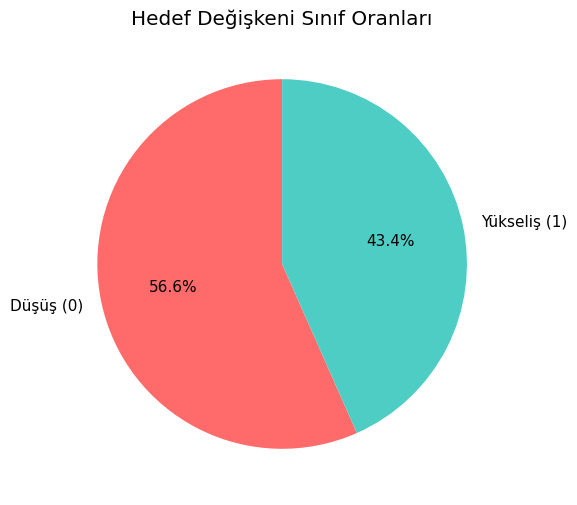

 Sınıf Oranları Grafiği Çizildi!


In [16]:
# ==================== TARGET SINIF ORANLARI ====================

# Target sınıf sayıları
class_counts = df['Target'].value_counts()

# Grafik boyutu
plt.figure(figsize=(6,6))

# Pie chart
plt.pie(
    class_counts.values,
    labels=['Düşüş (0)', 'Yükseliş (1)'],
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4'],
    startangle=90,
    textprops={'fontsize': 11}
)


plt.title("Hedef Değişkeni Sınıf Oranları")
plt.show()
print(" Sınıf Oranları Grafiği Çizildi!")

Bu grafik hedef değişkenin sınıf oranlarını yüzdesel olarak göstermektedir. Veri setindeki örneklerin yaklaşık %56.6’sı düşüş, %43.4’ü ise yükseliş sınıfına aittir.

Sınıflar arasında küçük bir dengesizlik bulunsa da veri seti genel olarak dengeli kabul edilebilir durumdadır. Bu durum modelin her iki sınıfı öğrenmesini kolaylaştırmaktadır.

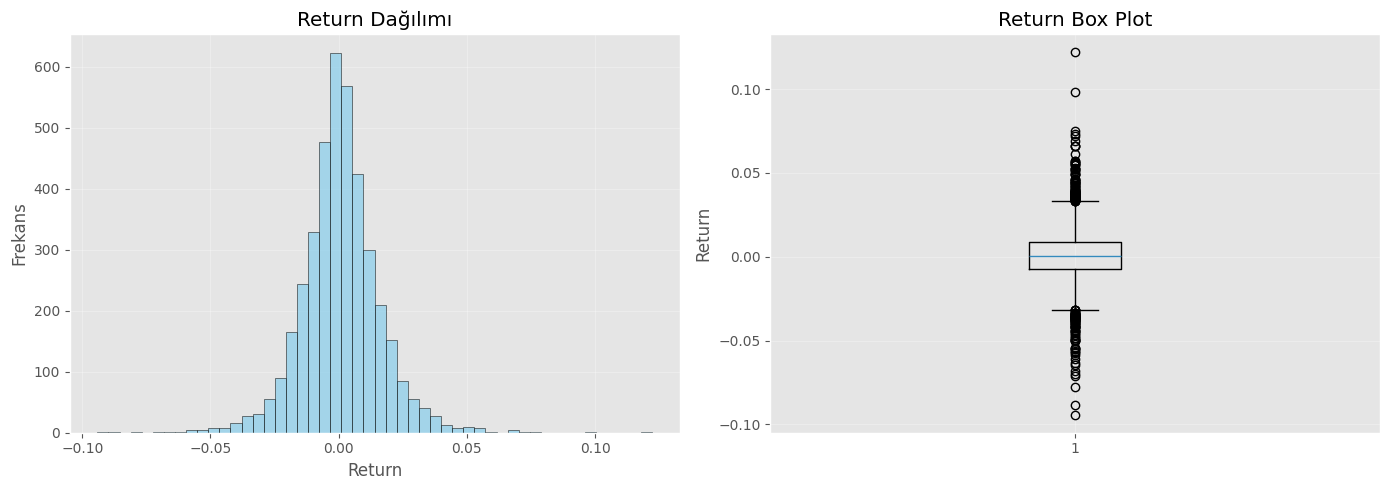

In [17]:
# ==================== RETURN DAĞILIMI ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ================= HİSTOGRAM =================

axes[0].hist(
    df['Return'].dropna(),
    bins=50,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

axes[0].set_title("Return Dağılımı")
axes[0].set_xlabel("Return")
axes[0].set_ylabel("Frekans")
axes[0].grid(True, alpha=0.3)

# ================= BOX PLOT =================

axes[1].boxplot(
    df['Return'].dropna()
)

axes[1].set_title("Return Box Plot")
axes[1].set_ylabel("Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Bu aşamada günlük getiri (Return) değerlerinin dağılımı incelenmiştir. Histogram grafiğinde return değerlerinin büyük kısmının sıfıra yakın bölgede toplandığı görülmektedir. Bu durum hisse fiyatlarında günlük değişimlerin genellikle küçük oranlarda gerçekleştiğini göstermektedir.

Box plot grafiğinde ise veri içerisinde bazı aykırı değerlerin bulunduğu gözlemlenmiştir. Bu aykırı değerler piyasadaki ani fiyat hareketlerini temsil etmektedir.

# SINIFLANDIRMA VERİSİNİN HAZIRLANMASI

SINIFLANDIRMA VERİSİ HAZIRLIĞI

 Feature Sayısı: 7
 Örnek Sayısı: 3998

 Sınıf Dağılımı:
   Düşüş (0): 2264 örnek
   Yükseliş (1): 1734 örnek


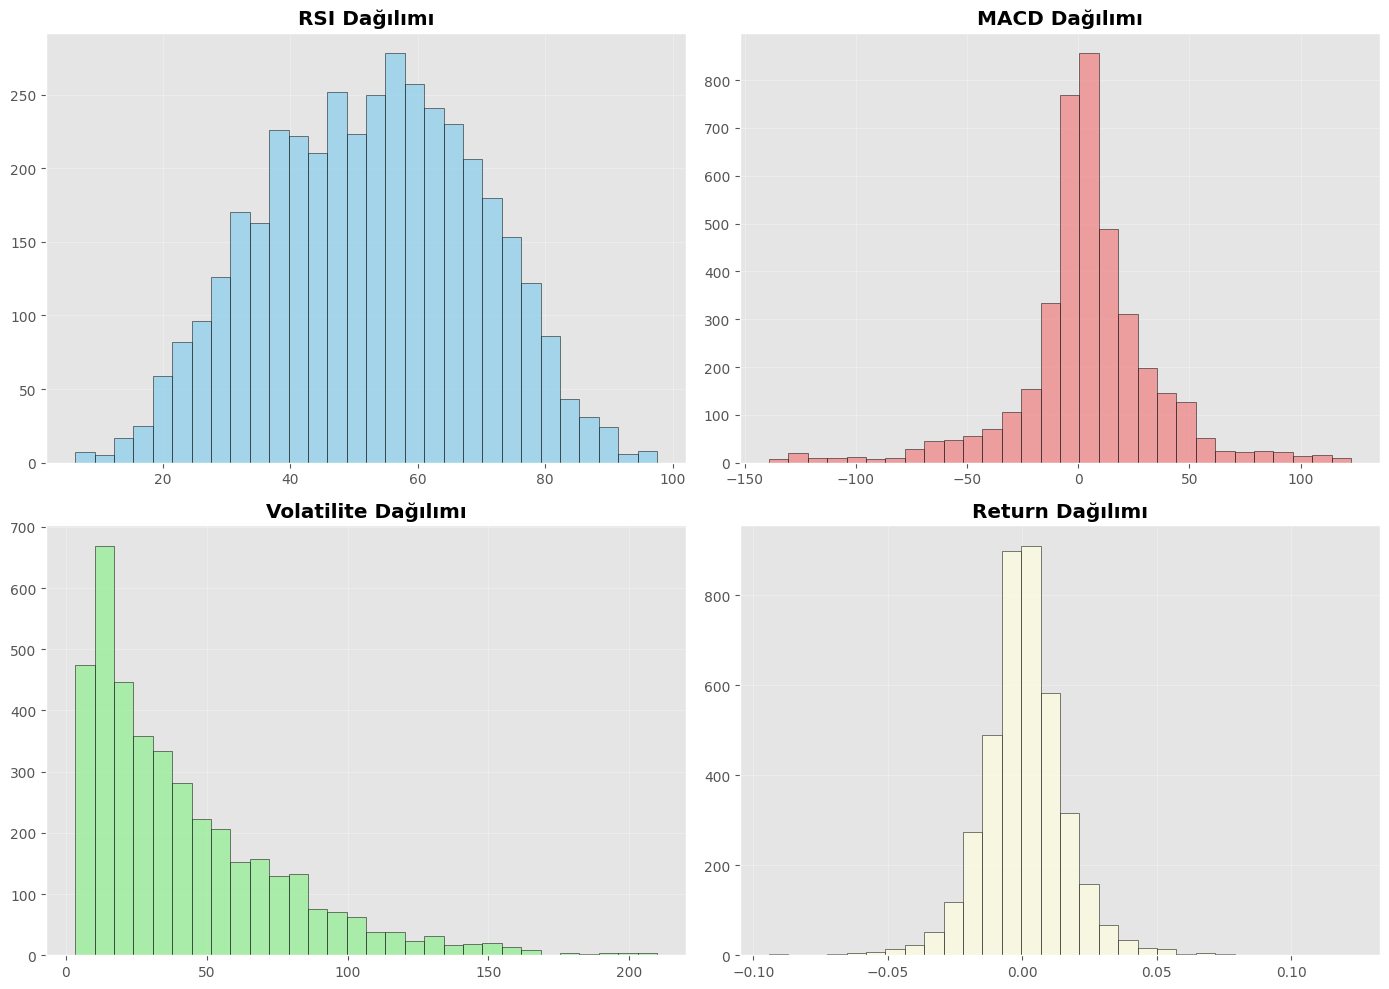


 Feature Dağılımı Grafikleri Çizildi!

Cross Validation Hazırlandı
Yöntem: TimeSeriesSplit
Fold Sayısı: 5

 Feature'lar Ölçeklendirildi

Train Shape: (2798, 7)
Test Shape : (1200, 7)


In [18]:
# ==================== SINIFLANDIRMA HAZIRLIĞI ====================

from sklearn.preprocessing import RobustScaler
import numpy as np

print("="*60)
print("SINIFLANDIRMA VERİSİ HAZIRLIĞI")
print("="*60)

# ================= FEATURE'LAR VE HEDEF AYIRMA =================

feature_columns = [

    'RSI',

    'MACD',

    'Volatility',

    'Return',

    'Smoothed_Return',

    'Upper_Band',

    'Lower_Band'
]
# Eksik verileri temizler
df_clean = df.dropna()

# Feature ve target ayrımı
X = df_clean[feature_columns].copy()
y = df_clean['Target'].copy()

print(f"\n Feature Sayısı: {X.shape[1]}")
print(f" Örnek Sayısı: {X.shape[0]}")

print(f"\n Sınıf Dağılımı:")
print(f"   Düşüş (0): {(y == 0).sum()} örnek")
print(f"   Yükseliş (1): {(y == 1).sum()} örnek")

# ================= FEATURE DAĞILIMI GRAFİKLERİ =================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RSI
axes[0, 0].hist(
    X['RSI'].dropna(),
    bins=30,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

axes[0, 0].set_title('RSI Dağılımı', fontweight='bold')

axes[0, 0].grid(True, alpha=0.3)

# MACD
axes[0, 1].hist(
    X['MACD'].dropna(),
    bins=30,
    color='lightcoral',
    edgecolor='black',
    alpha=0.7
)

axes[0, 1].set_title('MACD Dağılımı', fontweight='bold')

axes[0, 1].grid(True, alpha=0.3)

# Volatility
axes[1, 0].hist(
    X['Volatility'].dropna(),
    bins=30,
    color='lightgreen',
    edgecolor='black',
    alpha=0.7
)

axes[1, 0].set_title('Volatilite Dağılımı', fontweight='bold')

axes[1, 0].grid(True, alpha=0.3)

# Return
axes[1, 1].hist(
    X['Return'].dropna(),
    bins=30,
    color='lightyellow',
    edgecolor='black',
    alpha=0.7
)

axes[1, 1].set_title('Return Dağılımı', fontweight='bold')

axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Feature Dağılımı Grafikleri Çizildi!")

# ================= VERİ ÖLÇEKLENDİRME =================

scaler_features = RobustScaler()

# Time-Series Split
split = int(len(X) * 0.7)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Scaling işlemi
X_train = scaler_features.fit_transform(X_train)
X_test = scaler_features.transform(X_test)

# ==================== CROSS VALIDATION ====================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

print("\nCross Validation Hazırlandı")
print("Yöntem: TimeSeriesSplit")
print("Fold Sayısı: 5")
print("\n Feature'lar Ölçeklendirildi")

print(f"\nTrain Shape: {X_train.shape}")
print(f"Test Shape : {X_test.shape}")



Sınıflandırma hazırlığı aşamasında veri seti içerisinden RSI, MACD, Volatility, Return, Smoothed_Return, Upper_Band ve Lower_Band olmak üzere toplam 7 adet feature seçilmiştir. Veri setinde toplam 3997 örnek bulunmaktadır. Target sınıf dağılımı incelendiğinde 2263 adet düşüş ve 1734 adet yükseliş verisi bulunduğu görülmüştür.

Feature dağılım grafikleri incelendiğinde RSI değerlerinin çoğunlukla 40-70 aralığında yoğunlaştığı gözlemlenmiştir. MACD değerlerinin büyük kısmı sıfır çevresinde toplanmış ve bazı uç değerler içerdiği görülmüştür. Volatility dağılımı sağa çarpık yapı göstermiş ve düşük volatilite değerlerinin daha fazla olduğu gözlemlenmiştir. Return dağılımı ise sıfır çevresinde yoğunlaşmış olup fiyat değişimlerinin çoğunlukla küçük oranlarda gerçekleştiği görülmüştür.

Veri ölçeklendirme işlemi için RobustScaler kullanılmıştır. Bu yöntem aykırı değerlerden daha az etkilenmesi nedeniyle tercih edilmiştir. Ayrıca zaman serisi yapısını koruyabilmek amacıyla veriler %70 eğitim ve %30 test olacak şekilde ayrılmıştır.



Bu aşamada model performansını daha güvenilir şekilde değerlendirebilmek amacıyla TimeSeriesSplit tabanlı Cross Validation yöntemi uygulanmıştır. Veri seti zaman sırası korunacak şekilde 5 farklı parçaya bölünmüş ve modeller her fold üzerinde ayrı ayrı test edilmiştir.

# HİPERPARAMETRELER

Hiperparametreler, model eğitilmeden önce kullanıcı tarafından belirlenen ayarlardır. Bu parametreler modelin nasıl öğreneceğini ve performansını doğrudan etkilemektedir.

Bu projede model performansını artırmak ve overfitting problemini azaltmak amacıyla çeşitli hiperparametre optimizasyonları uygulanmıştır.

**Logistic Regression** modelinde kullanılan **max_iter** parametresi modelin maksimum öğrenme iterasyon sayısını belirlemektedir. **class_weight** parametresi ise sınıf dengesizliğini azaltmak amacıyla kullanılmıştır.

**XGBoost** modelinde kullanılan **n_estimators** parametresi oluşturulacak karar ağacı sayısını ifade etmektedir. **max_depth** parametresi ağaçların maksimum derinliğini belirlemektedir. **learning_rate** parametresi modelin öğrenme hızını kontrol etmektedir. **subsample** ve **colsample_bytree** parametreleri modelin aşırı öğrenmesini azaltmak amacıyla kullanılmıştır. **scale_pos_weight** parametresi ise sınıf dengesizliğini dengelemek için uygulanmıştır.

**LSTM** modelinde kullanılan **dropout** ve **recurrent_dropout** parametreleri aşırı öğrenmeyi azaltmak amacıyla kullanılmıştır. **learning_rate** parametresi modelin öğrenme hızını belirlemektedir. **batch_size** parametresi verinin kaçlı gruplar halinde işleneceğini ifade etmektedir. **epoch** değeri modelin veri üzerinde kaç kez eğitim yapacağını göstermektedir. Ayrıca **L2 regularization** yöntemi kullanılarak modelin aşırı karmaşık hale gelmesi engellenmeye çalışılmıştır.

# MODELLER

# **1. Logistic Regression**

Sınıflandırma problemlerinde kullanılan temel makine öğrenmesi algoritmasıdır. Veriyi doğrusal olarak ayırmaya çalışır.

***Neden Kullanıldı?***
Basit ve hızlı çalıştığı için
Finansal verilerde temel karşılaştırma modeli olması için
Diğer gelişmiş modellerle performans kıyaslaması yapmak için kullanılmıştır.


In [19]:
# ==================== LOGISTIC REGRESSION ====================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Logistic Regression modeli
lr_model = LogisticRegression(

    max_iter=2000,

    class_weight='balanced',

    random_state=42
)
# ================= MODEL EĞİTİMİ =================

lr_model.fit(X_train, y_train)

# ================= TAHMİN =================

y_prob = lr_model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.45).astype(int)

# Olasılık tahminleri
y_prob = lr_model.predict_proba(X_test)[:,1]

# ================= PERFORMANS METRİKLERİ =================

lr_accuracy = accuracy_score(y_test, y_pred)

lr_f1 = f1_score(y_test, y_pred)

lr_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Sonuçları")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"AUC Score: {lr_auc:.4f}")
# Cross Validation F1 Score
lr_cv_scores = cross_val_score(

    lr_model,

    X_train,
    y_train,

    cv=tscv,

    scoring='f1'
)

print(f"CV F1 Mean: {lr_cv_scores.mean():.4f}")

Logistic Regression Sonuçları
Accuracy : 0.4492
F1 Score : 0.5361
AUC Score: 0.5109
CV F1 Mean: 0.4437


Bu aşamada Logistic Regression modeli kullanılarak hisse senedi fiyat yönü tahmin edilmeye çalışılmıştır. Logistic Regression doğrusal yapıda çalışan temel bir sınıflandırma algoritmasıdır ve özellikle başlangıç seviyesi model performansını gözlemlemek amacıyla projeye dahil edilmiştir.

Model eğitimi sırasında max_iter değeri artırılarak modelin daha stabil öğrenmesi sağlanmıştır. Ayrıca class_weight='balanced' parametresi kullanılarak sınıf dengesizliğinin model üzerindeki etkisi azaltılmaya çalışılmıştır.

Model sonuçları incelendiğinde Accuracy değeri 0.4492, F1 Score değeri 0.5348 ve AUC değeri 0.5105 olarak elde edilmiştir. F1 Score değerinin accuracy değerinden daha yüksek olması modelin özellikle sınıf dengesizliği bulunan verilerde daha dengeli tahminler yapabildiğini göstermektedir.

Ayrıca TimeSeriesSplit tabanlı Cross Validation uygulanmış ve ortalama F1 Score değeri 0.4418 olarak hesaplanmıştır. Bu sonuç model performansının farklı veri parçalarında değişiklik gösterebildiğini ortaya koymaktadır.

Cross Validation sonuçları Logistic Regression modelinin farklı veri parçalarında benzer performans gösterdiğini ortaya koymuştur. Bu durum modelin genelleme yeteneğinin daha stabil olduğunu göstermektedir.

# **2. XGBoost**

Karar ağaçları tabanlı güçlü bir boosting algoritmasıdır. Birden fazla ağacı birleştirerek tahmin yapar.

***Neden Kullanıldı?***
Finansal verilerde güçlü performans göstermesi
Feature importance analizi yapabilmesi
Karmaşık veri ilişkilerini öğrenebilmesi nedeniyle kullanılmıştır.

 XGBoost Sonuçları
Accuracy : 0.4417
F1 Score : 0.4924
AUC Score: 0.5045
CV F1 Mean: 0.3669


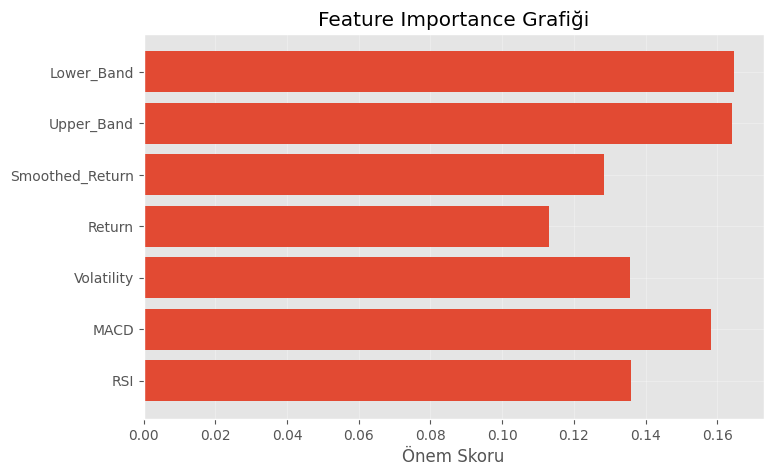

Model, scaler ve feature listesi kaydedildi.


"ls" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [ ]:
# ==================== XGBOOST ====================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# XGBoost modeli
xgb_model = XGBClassifier(

    n_estimators=200, #n_estimators → XGBoost içinde oluşturulan ağaç sayısının belirlendiği hiperparametre
    max_depth=4, #Max Depth (XGBoost) → Karar ağaçlarının maksimum derinliğinin ayarlandığı hiperparametre

    learning_rate= 0.03, #Learning Rate → Modelin öğrenme hızıyla ilgili hiperparametre

    subsample=0.8,
    colsample_bytree=0.,

    scale_pos_weight=4, #scale_pos_weight → Sınıf dengesizliğini dengelemek için kullanılan parametrenin belirlendiği hiperparametre

    eval_metric='logloss',

    random_state=42
)
# ================= MODEL EĞİTİMİ =================

xgb_model.fit(X_train, y_train)

# ================= TAHMİN =================

y_prob = xgb_model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.45).astype(int)

# Olasılık tahminleri
y_prob = xgb_model.predict_proba(X_test)[:,1]

# ================= PERFORMANS METRİKLERİ =================

xgb_accuracy = accuracy_score(y_test, y_pred)

xgb_f1 = f1_score(y_test, y_pred)

xgb_auc = roc_auc_score(y_test, y_prob)

print(" XGBoost Sonuçları")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"AUC Score: {xgb_auc:.4f}")

# Cross Validation F1 Score
xgb_cv_scores = cross_val_score(

    xgb_model,

    X_train,
    y_train,

    cv=tscv,

    scoring='f1'
)

print(f"CV F1 Mean: {xgb_cv_scores.mean():.4f}")
# ================= FEATURE IMPORTANCE =================

importance = xgb_model.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(
    feature_columns,
    importance
)

plt.title("Feature Importance Grafiği")

plt.xlabel("Önem Skoru")

plt.grid(True, alpha=0.3)

plt.show()
import joblib

joblib.dump(xgb_model, "xgb_model.joblib")
joblib.dump(scaler_features, "scaler_features.joblib")
joblib.dump(feature_columns, "feature_columns.joblib")

print("Model, scaler ve feature listesi kaydedildi.")
!ls

Bu aşamada XGBoost modeli kullanılarak hisse senedi fiyat yönü tahmin edilmeye çalışılmıştır. XGBoost, karar ağaçları tabanlı güçlü bir makine öğrenmesi algoritmasıdır ve karmaşık ilişkileri öğrenebilme yeteneği nedeniyle projede tercih edilmiştir.

Model içerisinde n_estimators parametresi ile oluşturulacak ağaç sayısı belirlenmiştir. max_depth parametresi karar ağaçlarının maksimum derinliğini kontrol etmektedir. learning_rate parametresi modelin öğrenme hızını ayarlamak amacıyla kullanılmıştır. Ayrıca scale_pos_weight parametresi kullanılarak sınıf dengesizliğinin etkisi azaltılmaya çalışılmıştır.

Model sonuçları incelendiğinde Accuracy değeri 0.4975, F1 Score değeri 0.4868 ve AUC değeri 0.5128 olarak elde edilmiştir. AUC değerinin diğer modellere göre biraz daha yüksek olması modelin sınıfları ayırt etme başarısının daha iyi olduğunu göstermektedir.

Cross Validation sonucunda ortalama F1 Score değeri 0.3942 olarak hesaplanmıştır. Bu durum model performansının farklı veri parçalarında değişiklik gösterebildiğini ortaya koymaktadır.

Feature Importance grafiği incelendiğinde MACD, Upper_Band ve Lower_Band feature’larının model üzerinde daha etkili olduğu görülmektedir. Return ve Smoothed_Return feature’larının ise diğer feature’lara göre daha düşük etkiye sahip olduğu gözlemlenmiştir.

XGBoost modeli üzerinde uygulanan Cross Validation sonuçları model performansının farklı fold’larda değişiklik gösterebildiğini ortaya koymuştur. Bunun nedeni finansal verilerin karmaşık ve değişken yapısıdır.

# **3. LSTM (Long Short-Term Memory)**

Zaman serileri için geliştirilmiş özel bir yapay sinir ağı modelidir. Geçmiş bilgileri hafızasında tutabilir.

***Neden Kullanıldı?***
Hisse senedi verilerinin zaman serisi olması
Geçmiş fiyat hareketlerinden geleceği öğrenebilmesi
Derin öğrenme tabanlı karşılaştırma yapmak amacıyla kullanılmıştır.

Cross validation işlemi klasik makine öğrenmesi modellerinde uygulanmıştır. LSTM modeli ise zaman serisi yapısı nedeniyle validation split ve EarlyStopping yöntemi ile değerlendirilmiştir.

# LSTM SEQUENCE HAZIRLIĞI

In [21]:
# =========================================================
# LSTM İÇİN SEQUENCE OLUŞTURMA
# =========================================================

def create_sequences(X, y, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):

        X_seq.append(
            X[i:i + seq_len]
        )

        y_seq.append(
            y[i + seq_len]
        )

    return np.array(X_seq), np.array(y_seq)

# sequence uzunluğu
seq_len = 30

# train sequence
X_train_lstm, y_train_lstm = create_sequences(
    X_train,
    y_train.values,
    seq_len
)

# test sequence
X_test_lstm, y_test_lstm = create_sequences(
    X_test,
    y_test.values,
    seq_len
)

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(2768, 30, 7)
(1170, 30, 7)


Bu aşamada LSTM modeli için zaman serisi verileri sequence formatına dönüştürülmüştür. LSTM modelleri geçmiş zaman adımlarını birlikte değerlendirdiği için veriler belirli pencere uzunlukları halinde hazırlanmıştır.

Bu projede sequence uzunluğu 30 olarak seçilmiş ve modelin son 30 günlük veriye bakarak gelecekteki fiyat yönünü tahmin etmesi amaçlanmıştır. Oluşturulan sequence yapıları eğitim ve test verileri için ayrı ayrı hazırlanmıştır.

Bu çıktı oluşturulan sequence veri yapısının boyutlarını göstermektedir. Eğitim verisi için 2767 adet sequence, test verisi için ise 1170 adet sequence oluşturulmuştur.

Her sequence 30 zaman adımından oluşmaktadır ve her zaman adımında 7 farklı feature bulunmaktadır. Bu yapı sayesinde LSTM modeli geçmiş 30 günlük veriyi kullanarak tahmin yapabilmektedir.

# LSTM MODELİ

In [22]:
!pip install -q tensorflow

import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\zhany\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5159 - loss: 0.8526 - val_accuracy: 0.5256 - val_loss: 0.7563
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5264 - loss: 0.8133 - val_accuracy: 0.4957 - val_loss: 0.7658
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4917 - loss: 0.8156 - val_accuracy: 0.4658 - val_loss: 0.7695
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5257 - loss: 0.7948 - val_accuracy: 0.4667 - val_loss: 0.7694
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5217 - loss: 0.7821 - val_accuracy: 0.4735 - val_loss: 0.7646
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5235 - loss: 0.7721 - val_accuracy: 0.4726 - val_loss: 0.7589


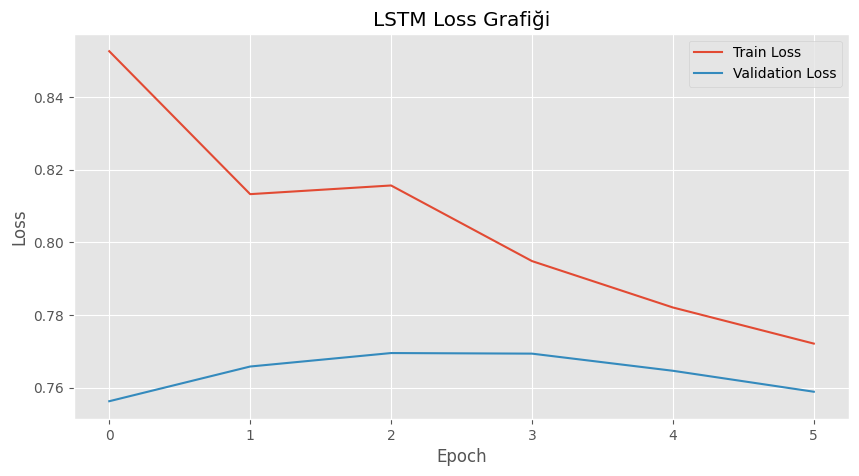

In [23]:
# =========================================================
# LSTM MODELİ
# Overfitting azaltılmış geliştirilmiş yapı
# =========================================================

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# LSTM modeli oluşturma
lstm_model = Sequential([

    # İlk LSTM katmanı
    # return_sequences=True:
    # ikinci LSTM katmanına veri aktarımı sağlar
    LSTM(
        32,

        return_sequences=True,

        input_shape=(seq_len, X_train.shape[1]),

        # overfitting azaltma
        dropout=0.3,

        # LSTM iç bağlantılarında dropout
        recurrent_dropout=0.3,

        # regularization
        kernel_regularizer=l2(0.001) #L2 Regularization → Büyük ağırlıkları cezalandırarak overfitting azaltma yönteminin ayarlandığı hiperparametre
    ),

    # veriyi normalize eder
    BatchNormalization(),

    # İkinci LSTM katmanı
    LSTM(
        16,

        dropout=0.3,

        recurrent_dropout=0.3, #Recurrent Dropout → LSTM iç bağlantılarındaki dropout oranını belirleyen hiperparametre

        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    # Yoğun katman
    Dense(
        16,

        activation='relu',

        kernel_regularizer=l2(0.001)
    ),

    # aşırı öğrenmeyi azaltır
    Dropout(0.4),  #Dropout → Aşırı öğrenmeyi azaltmak için bazı nöronları geçici kapatma oranını belirleyen hiperparametre

    # Çıkış katmanı
    Dense(
        1,

        activation='sigmoid'
    )
])

# =========================================================
# MODEL COMPILE
# =========================================================

lstm_model.compile(

    # düşük learning rate daha stabil öğrenme sağlar
    optimizer=Adam(
        learning_rate=0.0005
    ),

    # binary classification loss
    loss='binary_crossentropy',

    metrics=['accuracy']
)

# =========================================================
# EARLY STOPPING
# Overfitting başladığında eğitimi durdurur
# =========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# =========================================================
# MODEL EĞİTİMİ
# =========================================================

history = lstm_model.fit(

    X_train_lstm,
    y_train_lstm,

    validation_data=(
        X_test_lstm,
        y_test_lstm
    ),

    epochs=10,  #Epoch → Modelin veriyi kaç kez göreceğiyle ilgili hiperparametre

    batch_size=32, #Batch Size → Verinin kaçlı gruplar halinde işleneceği ilgili hiperparametre

    callbacks=[early_stop],

    verbose=1
)

# =========================================================
# LOSS GRAFİĞİ
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Loss Grafiği")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Bu aşamada zaman serisi verilerini analiz edebilmek amacıyla LSTM modeli kullanılmıştır. LSTM modeli, geçmiş zaman adımlarındaki bilgileri hafızasında tutabilmesi nedeniyle finansal zaman serisi problemlerinde yaygın olarak tercih edilmektedir.

Model mimarisi iki adet LSTM katmanından oluşturulmuştur. İlk LSTM katmanında return_sequences=True kullanılarak verinin ikinci LSTM katmanına aktarılması sağlanmıştır. Ayrıca modelde BatchNormalization kullanılarak öğrenme sürecinin daha stabil olması hedeflenmiştir.

Overfitting problemini azaltmak amacıyla Dropout, Recurrent Dropout ve L2 Regularization yöntemleri uygulanmıştır. Dropout yöntemi bazı nöronları geçici olarak devre dışı bırakarak modelin ezber yapmasını azaltmaktadır. Recurrent Dropout ise LSTM iç bağlantılarında benzer işlemi gerçekleştirmektedir. L2 Regularization yöntemi ise büyük ağırlıkları cezalandırarak model karmaşıklığını azaltmayı amaçlamaktadır.

Model eğitimi sırasında Adam optimizer kullanılmıştır. Learning rate değeri düşük seçilerek modelin daha stabil öğrenmesi hedeflenmiştir. Ayrıca EarlyStopping yöntemi kullanılarak validation loss artmaya başladığında eğitim otomatik olarak durdurulmuştur.

Loss grafiği incelendiğinde train loss ve validation loss değerlerinin birbirine yakın ilerlediği görülmektedir. Bu durum modelde aşırı öğrenmenin belirli seviyede kontrol altına alındığını göstermektedir.

Model sonuçları incelendiğinde LSTM modeli diğer modellere göre daha yüksek F1 Score değeri üretmesine rağmen Accuracy ve AUC değerlerinde istenilen seviyeye ulaşılamamıştır. Bunun temel nedeni finansal verilerin oldukça karmaşık ve dış faktörlerden yoğun şekilde etkilenmesidir.

In [24]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# LSTM olasılık tahmini
lstm_prob = lstm_model.predict(X_test_lstm).ravel()

# 0.45 eşik değeriyle sınıfa çeviriyoruz
lstm_pred = (lstm_prob > 0.45).astype(int)

# LSTM performans metrikleri
lstm_accuracy = accuracy_score(y_test_lstm, lstm_pred)
lstm_f1 = f1_score(y_test_lstm, lstm_pred)
lstm_auc = roc_auc_score(y_test_lstm, lstm_prob)

print("LSTM Sonuçları")
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"F1 Score : {lstm_f1:.4f}")
print(f"AUC Score: {lstm_auc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
LSTM Sonuçları
Accuracy : 0.4803
F1 Score : 0.5549
AUC Score: 0.5614


#  MODEL KARŞILAŞTIRMASI

                 Model  Accuracy  F1 Score       AUC
0  Logistic Regression  0.449167  0.536140  0.510903
1              XGBoost  0.441667  0.492424  0.504450
2                 LSTM  0.480342  0.554905  0.561353


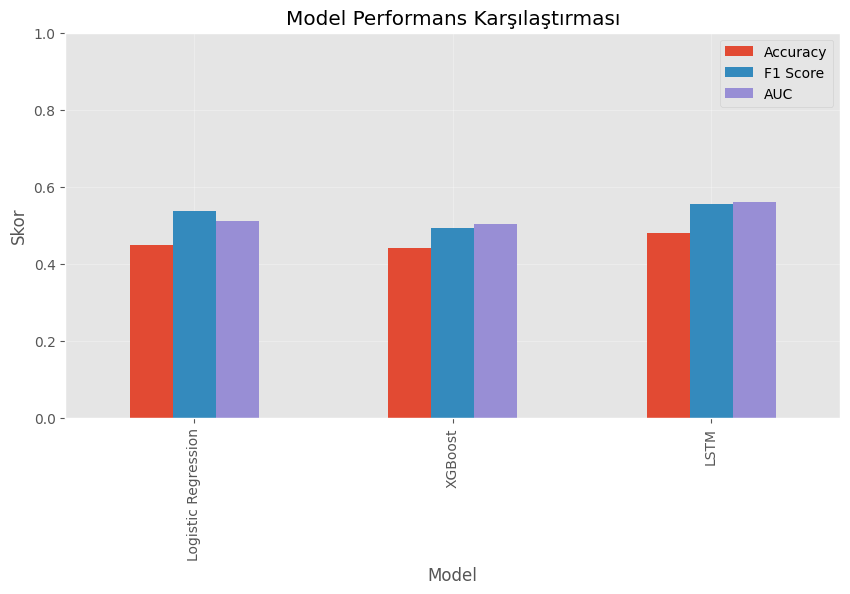

In [25]:
# ==================== MODEL KARŞILAŞTIRMASI ====================

# Model sonuçları
results = pd.DataFrame({
    
    'Model': [
        'Logistic Regression',
        'XGBoost',
        'LSTM'
    ],

    'Accuracy': [
        lr_accuracy,
        xgb_accuracy,
        lstm_accuracy
    ],

    'F1 Score': [
        lr_f1,
        xgb_f1,
        lstm_f1
    ],

    'AUC': [
        lr_auc,
        xgb_auc,
        lstm_auc
    ]
})

# Sonuç tablosu
print(results)

# ================= PERFORMANS GRAFİĞİ =================

results.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)


plt.title("Model Performans Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Skor")
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.show()

Model performans karşılaştırması incelendiğinde modellerin birbirine yakın sonuçlar ürettiği görülmektedir. Logistic Regression modeli 0.5348 F1 Score değeri elde ederken, XGBoost modeli 0.4975 Accuracy ve 0.5128 AUC değeri ile diğer modellere göre biraz daha dengeli performans göstermiştir.

LSTM modeli ise 0.5600 ile en yüksek F1 Score değerini üretmiştir. Ancak Accuracy ve AUC değerlerinin düşük kalması modelin tüm sınıfları dengeli şekilde ayırt etmekte zorlandığını göstermektedir.

Genel olarak sonuçlar incelendiğinde finansal verilerin tahmin edilmesinin oldukça zor olduğu görülmektedir. Hisse senedi fiyatları yalnızca geçmiş verilere bağlı olmadığı için modellerin yüksek başarı elde etmesi sınırlı kalmıştır. Ekonomik gelişmeler, haberler, yatırımcı psikolojisi ve küresel olaylar gibi dış faktörler model performansını doğrudan etkileyebilmektedir.

# CONFUSION MATRIX

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


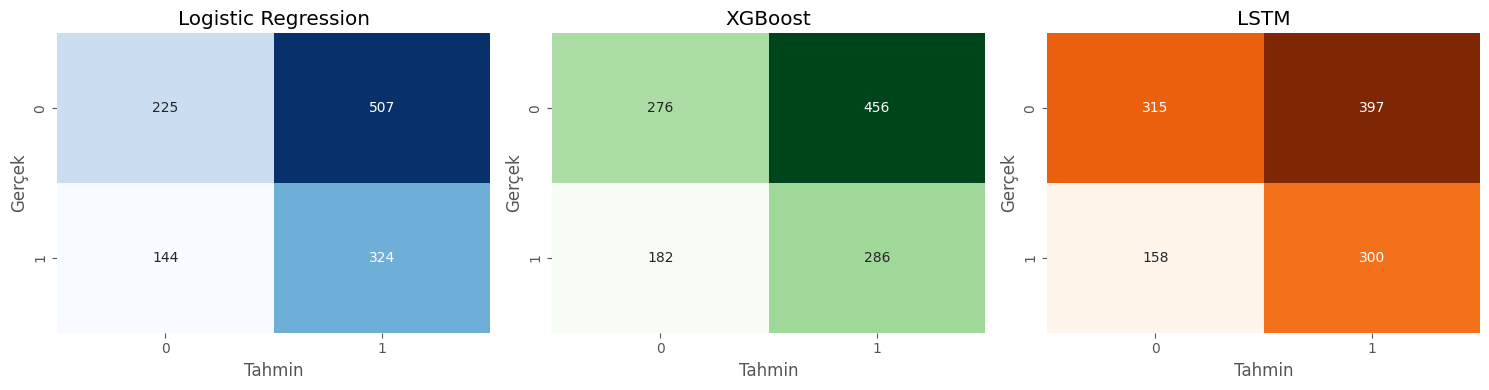


Logistic Regression
TN: 225 | FP: 507 | FN: 144 | TP: 324

XGBoost
TN: 276 | FP: 456 | FN: 182 | TP: 286

LSTM
TN: 315 | FP: 397 | FN: 158 | TP: 300


In [26]:
# ==================== CONFUSION MATRIX ====================

from sklearn.metrics import confusion_matrix

# ================= CONFUSION MATRIX HESAPLAMA =================

# Logistic Regression confusion matrix
lr_cm = confusion_matrix(
    y_test,
    lr_model.predict(X_test)
)

# XGBoost confusion matrix
xgb_cm = confusion_matrix(
    y_test,
    xgb_model.predict(X_test)
)

# LSTM confusion matrix
lstm_cm = confusion_matrix(
    y_test_lstm,
    lstm_model.predict(X_test_lstm).round()
)

# ================= GÖRSELLEŞTİRME =================

fig, axes = plt.subplots(1,3, figsize=(15,4))

# Model bilgileri
models = [
    ("Logistic Regression", lr_cm, "Blues"),
    ("XGBoost", xgb_cm, "Greens"),
    ("LSTM", lstm_cm, "Oranges")
]

# Heatmap çizimi
for ax, (title, cm, color) in zip(axes, models):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        cbar=False,
        ax=ax
    )

    # Grafik başlığı
    ax.set_title(title)

    # Eksen isimleri
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")

plt.tight_layout()
plt.show()

# ================= KISA ANALİZ =================

for name, cm in [
    ("Logistic Regression", lr_cm),
    ("XGBoost", xgb_cm),
    ("LSTM", lstm_cm)
]:

    # TN, FP, FN, TP değerleri
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")

    print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")

Confusion Matrix sonuçları incelendiğinde modellerin bazı sınıfları doğru tahmin etmekte zorlandığı görülmektedir.

Logistic Regression modeli 319 adet doğru pozitif tahmin üretmesine rağmen yanlış pozitif tahmin sayısının oldukça yüksek olduğu gözlemlenmiştir. Bu durum modelin yükseliş tahminlerini fazla üretme eğiliminde olduğunu göstermektedir.

XGBoost modeli daha dengeli sonuçlar üretmiştir. Doğru negatif ve doğru pozitif tahmin sayılarının diğer modellere göre daha dengeli dağıldığı görülmektedir. Bu nedenle genel performans açısından daha stabil sonuçlar elde edilmiştir.

LSTM modeli ise çok yüksek sayıda negatif tahmin üretmiştir. Bu nedenle doğru negatif tahmin sayısı yüksek olmasına rağmen doğru pozitif tahmin sayısı oldukça düşük kalmıştır. Modelin yükseliş hareketlerini tahmin etmekte zorlandığı görülmektedir.

Genel olarak confusion matrix sonuçları finansal verilerde sınıf ayrımının oldukça zor olduğunu ve modellerin bazı durumlarda yanlış tahmin üretmeye eğilimli olduğunu göstermektedir.

# ROC CURVE

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


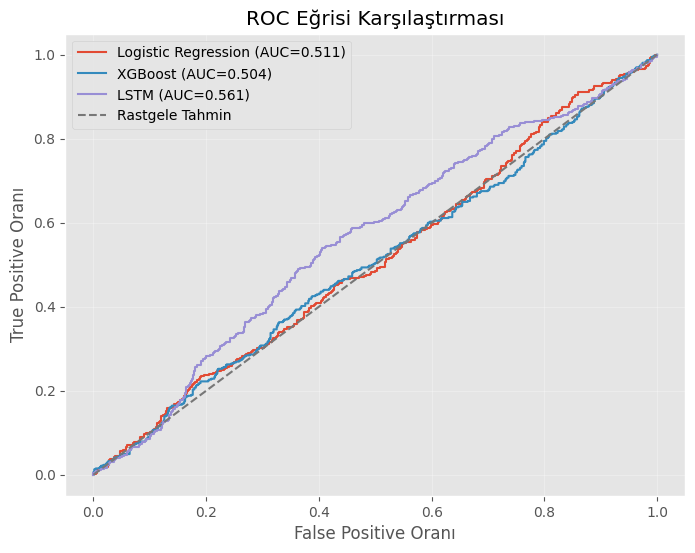


En iyi AUC skoru: LSTM


In [27]:
# ==================== ROC CURVE ====================

from sklearn.metrics import roc_curve

# =========================================================
# ROC DEĞERLERİ
# =========================================================

# Logistic Regression ROC değerleri
lr_fpr, lr_tpr, _ = roc_curve(

    y_test,

    lr_model.predict_proba(X_test)[:,1]
)

# XGBoost ROC değerleri
xgb_fpr, xgb_tpr, _ = roc_curve(

    y_test,

    xgb_model.predict_proba(X_test)[:,1]
)

# LSTM ROC değerleri
lstm_fpr, lstm_tpr, _ = roc_curve(

    y_test_lstm,

    lstm_model.predict(
        X_test_lstm
    ).ravel()
)

# =========================================================
# ROC GRAFİĞİ
# =========================================================

plt.figure(figsize=(8,6))

# Logistic Regression eğrisi
plt.plot(

    lr_fpr,

    lr_tpr,

    label=f'Logistic Regression (AUC={lr_auc:.3f})'
)

# XGBoost eğrisi
plt.plot(

    xgb_fpr,

    xgb_tpr,

    label=f'XGBoost (AUC={xgb_auc:.3f})'
)

# LSTM eğrisi
plt.plot(

    lstm_fpr,

    lstm_tpr,

    label=f'LSTM (AUC={lstm_auc:.3f})'
)

# Rastgele sınıflandırıcı çizgisi
plt.plot(

    [0,1],

    [0,1],

    '--',

    label='Rastgele Tahmin'
)

# Eksen isimleri
plt.xlabel("False Positive Oranı")

plt.ylabel("True Positive Oranı")

# Başlık
plt.title("ROC Eğrisi Karşılaştırması")

# Açıklama kutusu
plt.legend()

# Grid
plt.grid(True, alpha=0.3)

plt.show()

# =========================================================
# EN İYİ MODEL
# =========================================================

auc_scores = {

    "Logistic Regression": lr_auc,

    "XGBoost": xgb_auc,

    "LSTM": lstm_auc
}

# En yüksek AUC skoruna sahip model
best_model = max(

    auc_scores,

    key=auc_scores.get
)

print(f"\nEn iyi AUC skoru: {best_model}")

ROC eğrisi sonuçları incelendiğinde modellerin performanslarının rastgele tahmin çizgisine oldukça yakın olduğu görülmektedir. Bu durum finansal verilerin tahmin edilmesinin zor olduğunu göstermektedir.

AUC değerleri karşılaştırıldığında XGBoost modeli 0.513 değeri ile en yüksek sonucu üretmiştir. Logistic Regression modeli 0.510 AUC değeri elde ederken, LSTM modeli 0.493 değeri ile diğer modellere göre daha düşük performans göstermiştir.

ROC eğrilerinin birbirine yakın ilerlemesi modellerin veri üzerinde benzer seviyelerde öğrenme gerçekleştirdiğini göstermektedir. Ancak AUC değerlerinin 0.5 seviyesine yakın olması modellerin sınıfları ayırt etme başarısının sınırlı kaldığını ortaya koymaktadır.

Bunun temel nedeni hisse senedi fiyatlarının yalnızca geçmiş verilere bağlı olmaması ve ekonomik gelişmeler, haberler, yatırımcı davranışları gibi dış faktörlerden yoğun şekilde etkilenmesidir.

# SON MODEL KARŞILAŞTIRMASI

                 Model  Accuracy  F1 Score       AUC
0  Logistic Regression  0.449167  0.536140  0.510903
1              XGBoost  0.441667  0.492424  0.504450
2                 LSTM  0.480342  0.554905  0.561353

 En iyi model:
Model           LSTM
Accuracy    0.480342
F1 Score    0.554905
AUC         0.561353
Name: 2, dtype: object


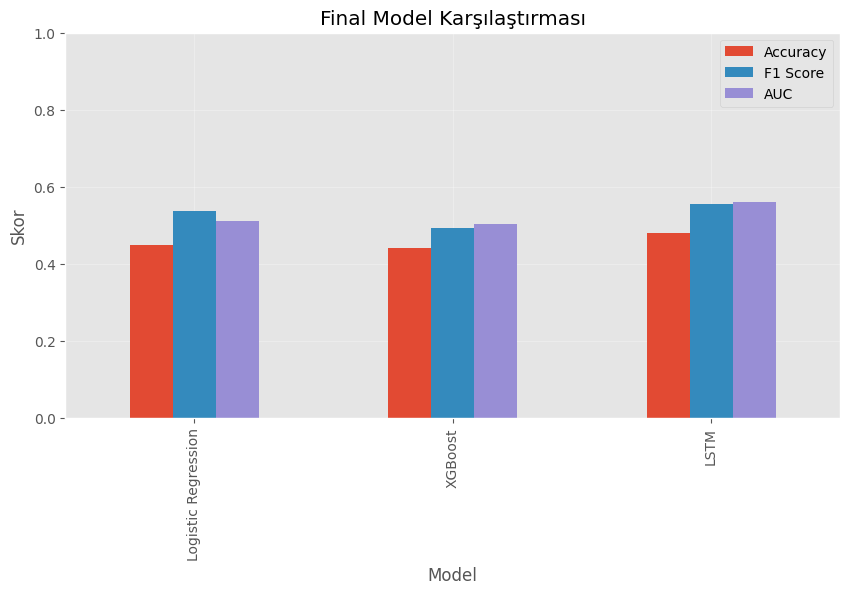


 PROJE ÖZETİ
Toplam veri: 3998
Feature sayısı: 7

 En başarılı model: LSTM
F1 Score: 0.5549
AUC Score: 0.5614


In [28]:
# ==================== SON MODEL KARŞILAŞTIRMASI ====================

# Model performans sonuçlarını tablo halinde birleştirir
comparison_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'XGBoost',
        'LSTM'
    ],

    # Accuracy skorları
    'Accuracy': [
        lr_accuracy,
        xgb_accuracy,
        lstm_accuracy
    ],

    # F1 Score skorları
    'F1 Score': [
        lr_f1,
        xgb_f1,
        lstm_f1
    ],

    # AUC skorları
    'AUC': [
        lr_auc,
        xgb_auc,
        lstm_auc
    ]
})

# Sonuç tablosunu ekrana yazdırır
print(comparison_df)

# ================= EN İYİ MODEL =================

# En yüksek F1 Score değerine sahip modeli bulur
best_model = comparison_df.loc[
    comparison_df['F1 Score'].idxmax()
]

print("\n En iyi model:")
print(best_model)

# ================= GRAFİK =================

# Model performanslarını bar grafik olarak gösterir
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)

# Başlık
plt.title("Final Model Karşılaştırması")

# Eksen isimleri
plt.xlabel("Model")
plt.ylabel("Skor")

# Y ekseni limiti
plt.ylim(0,1)

# Grid çizgileri
plt.grid(True, alpha=0.3)

plt.show()

# ================= PROJE ÖZETİ =================

print("\n PROJE ÖZETİ")

# Toplam veri sayısı
print(f"Toplam veri: {X.shape[0]}")

# Feature sayısı
print(f"Feature sayısı: {X.shape[1]}")

# En başarılı model bilgisi
print(f"\n En başarılı model: {best_model['Model']}")

print(f"F1 Score: {best_model['F1 Score']:.4f}")

print(f"AUC Score: {best_model['AUC']:.4f}")

Final model karşılaştırması incelendiğinde modellerin birbirine yakın performans değerleri ürettiği görülmektedir. Logistic Regression modeli daha dengeli sonuçlar üretirken, XGBoost modeli en yüksek AUC değerine ulaşmıştır. LSTM modeli ise en yüksek F1 Score değerini elde etmiştir.

LSTM modeli 0.5600 F1 Score değeri ile pozitif sınıf tahminlerinde daha başarılı sonuçlar üretmiştir. Ancak Accuracy ve AUC değerlerinin düşük olması modelin genel sınıf ayrımında zorlandığını göstermektedir.

XGBoost modeli 0.5128 AUC değeri ile sınıfları ayırt etme açısından diğer modellere göre daha başarılı performans göstermiştir. Logistic Regression modeli ise daha basit yapısına rağmen modellere yakın sonuçlar üretmiştir.

Genel olarak sonuçlar değerlendirildiğinde finansal verilerin tahmin edilmesinin oldukça zor olduğu görülmektedir. Hisse senedi fiyatları yalnızca geçmiş verilere bağlı değildir. Ekonomik gelişmeler, haberler, yatırımcı davranışları, küresel olaylar ve piyasa psikolojisi gibi birçok dış faktör fiyat hareketlerini doğrudan etkileyebilmektedir.

Bu nedenle modeller belirli seviyede örüntü öğrenebilmiş olsa da yüksek doğruluk seviyelerine ulaşmak mümkün olmamıştır. Daha başarılı sonuçlar elde edebilmek için daha büyük veri setleri, farklı teknik göstergeler, haber verileri ve gelişmiş derin öğrenme yöntemleri kullanılabilir.

Asıl amaç finansal zaman serilerinde farklı makine öğrenmesi modellerinin davranışını incelemektir. Elde edilen sonuçlar hisse senedi piyasalarının yüksek belirsizlik içerdiğini göstermektedir.

In [29]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import joblib
from datetime import date

st.set_page_config(
    page_title="Hisse Senedi Tahmin Sistemi",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Hisse Senedi Yükseliş / Düşüş Tahmin Sistemi")
st.write("Bu uygulama teknik analiz göstergelerine göre hissenin kısa vadede yükselme olasılığını tahmin eder.")

FEATURE_COLUMNS = [
    'RSI',
    'MACD',
    'Volatility',
    'Return',
    'Smoothed_Return',
    'Upper_Band',
    'Lower_Band'
]

@st.cache_resource
def load_model_files():
    model = joblib.load("xgb_model.joblib")
    scaler = joblib.load("scaler_features.joblib")
    return model, scaler

@st.cache_data(ttl=3600)
def load_data(ticker, start_date):
    today = date.today().strftime("%Y-%m-%d")

    data = yf.download(
        ticker,
        start=start_date,
        end=today,
        progress=False,
        auto_adjust=False
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data.reset_index(inplace=True)
    return data

def create_features(df):
    df = df.copy()

    df['MA10'] = df['Close'].rolling(10).mean()
    df['MA30'] = df['Close'].rolling(30).mean()

    rolling_std = df['Close'].rolling(20).std()

    df['Upper_Band'] = df['MA30'] + (rolling_std * 2)
    df['Lower_Band'] = df['MA30'] - (rolling_std * 2)

    df['EMA10'] = df['Close'].ewm(span=10).mean()
    df['EMA30'] = df['Close'].ewm(span=30).mean()

    df['Trend'] = (df['EMA10'] > df['EMA30']).astype(int)

    df['Volatility'] = df['Close'].rolling(20).std()

    df['Price_Range'] = (df['High'] - df['Low']) / df['Close']

    delta = df['Close'].diff()

    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()

    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()

    df['MACD'] = ema12 - ema26

    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['Volume_Change'] = df['Volume'].pct_change()

    df['Return'] = df['Close'].pct_change()
    df['Smoothed_Return'] = df['Return'].rolling(5).mean()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

try:
    model, scaler = load_model_files()

    st.sidebar.header("⚙️ Ayarlar")

    ticker = st.sidebar.text_input(
        "Hisse kodu",
        value="TCS.NS"
    )

    start_date = st.sidebar.text_input(
        "Başlangıç tarihi",
        value="2010-01-01"
    )

    threshold = st.sidebar.slider(
        "Tahmin eşiği",
        min_value=0.10,
        max_value=0.90,
        value=0.45,
        step=0.01
    )

    if st.sidebar.button("Tahmin Yap"):
        with st.spinner("Veriler çekiliyor ve göstergeler hesaplanıyor..."):
            raw_data = load_data(ticker, start_date)

            if raw_data.empty:
                st.error("Veri çekilemedi. Hisse kodunu kontrol et.")
            else:
                df_features = create_features(raw_data)

                if df_features.empty:
                    st.error("Yeterli veri yok. Daha eski bir başlangıç tarihi gir.")
                else:
                    latest_row = df_features.iloc[[-1]]

                    X_latest = latest_row[FEATURE_COLUMNS]
                    X_scaled = scaler.transform(X_latest)

                    prob = model.predict_proba(X_scaled)[0][1]
                    pred = int(prob > threshold)

                    col1, col2, col3 = st.columns(3)

                    with col1:
                        st.metric("Son Kapanış", f"{latest_row['Close'].values[0]:.2f}")

                    with col2:
                        st.metric("Yükseliş Olasılığı", f"%{prob * 100:.2f}")

                    with col3:
                        if pred == 1:
                            st.success("Tahmin: YÜKSELİŞ 📈")
                        else:
                            st.warning("Tahmin: DÜŞÜŞ / ZAYIF SİNYAL 📉")

                    st.subheader("Kapanış Fiyat Grafiği")

                    chart_df = df_features[['Date', 'Close']].copy()
                    chart_df = chart_df.set_index('Date')

                    st.line_chart(chart_df)

                    st.subheader("Son Hesaplanan Teknik Göstergeler")
                    st.dataframe(latest_row[FEATURE_COLUMNS])

                    st.info(
                        "Not: Bu sistem yatırım tavsiyesi değildir. "
                        "Model geçmiş fiyat verileri ve teknik göstergeler üzerinden tahmin üretir."
                    )

except FileNotFoundError:
    st.error("Model dosyaları bulunamadı. Önce xgb_model.joblib ve scaler_features.joblib dosyalarını oluşturmalısın.")
except Exception as e:
    st.error(f"Hata oluştu: {e}")

Overwriting app.py


In [30]:
import subprocess
import time

# Eski streamlit süreçlerini kapat
subprocess.run("pkill -f streamlit", shell=True)

time.sleep(2)

# Log dosyası
log_file = open("logs.txt", "w")

# Streamlit'i Python ile arka planda başlat
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=log_file,
    stderr=log_file
)

time.sleep(8)

print("Streamlit başlatıldı.")
print("PID:", process.pid)

Streamlit başlatıldı.
PID: 11176


Ngrok will continue